In this code we model specific 1D energy profiles of the Breit-Wheeler cross-section derived from particular slices of the phase space. The code evaluates the cross-section behavior for fixed gamma-ray energies 100TeV and 1PeV across target photon energies and for fixed interaction angles pi and pi/4. This allows us to examine how energy thresholds and collision geometry dictate high-energy gamma-ray absorption. It outputs a 1D line plot illustrating the energy-dependent cross-section curves explicitly identifying the peak interaction thresholds for 100TeV and 1PeV gamma rays against cosmic background radiation fields.

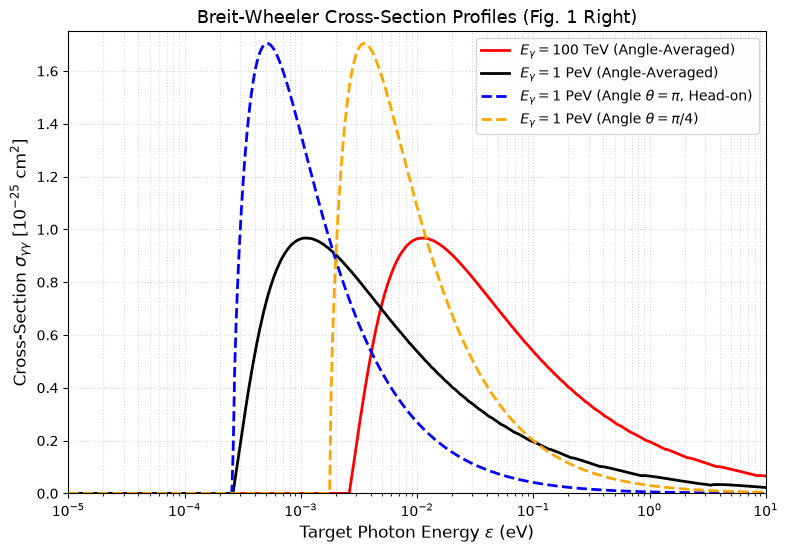

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Defining phase space
E_gamma = np.logspace(11,17,500)
epsilon = np.logspace(-5,1,500)
theta = np.linspace(0,360,360)
# x = 2(mc^2)^2
x = 5.2224e11 
# y = constant of sigma
y = 1.25e-25


# Defining cross-section functions
def s(E_gamma,epsilon,theta):
    theta_rad = np.radians(theta)
    result = E_gamma*epsilon*(1-np.cos(theta_rad))/x
    return result

def B(s):
    if s >= 1:
        B = np.sqrt(1-1/s)
        return B
    else:
        return 0.0

def sigma(B):
    if B==0:
        return 0.0
    else:
        result = y*(1-B**2)*((3-B**4)*np.log((1+B)/(1-B))-2*B*(2-B**2))
        return result


# Defining angle averaged cross section values (for 100TeV and 1Pev)
def angle_averaged_sigma(E_gamma, epsilon):
    sigmas = []
    for eps in epsilon:
        sigma_sum = 0.0
        for th in theta:
            s_val = s(E_gamma, eps, th)
            B_val = B(s_val)
            sigma_sum += sigma(B_val)
        sigmas.append(sigma_sum / len(theta))
    return np.array(sigmas)

# Defining cross section values for a fixed angle (for pi and pi/4)
def fixed_angle_sigma(E_gamma, epsilon, theta):
    sigmas = []
    for eps in epsilon:
        s_val = s(E_gamma, eps, theta)
        B_val = B(s_val)
        sigmas.append(sigma(B_val))
    return np.array(sigmas)

# Calculating cross section values for the intended values
sigma_100TeV_avg = angle_averaged_sigma(100e12, epsilon)
sigma_1PeV_avg = angle_averaged_sigma(1e15, epsilon)
sigma_1PeV_headon = fixed_angle_sigma(1e15, epsilon, 180.0)
sigma_1PeV_45deg = fixed_angle_sigma(1e15, epsilon, 45.0)


# Plotting lines for all 4 calculations
plt.figure(figsize=(9, 6))
plt.plot(epsilon, sigma_100TeV_avg * 1e25, color='r', linestyle='-', linewidth=2, 
         label=r'$E_\gamma = 100\text{ TeV (Angle-Averaged)}$')
plt.plot(epsilon, sigma_1PeV_avg * 1e25, color='k', linestyle='-', linewidth=2, 
         label=r'$E_\gamma = 1\text{ PeV (Angle-Averaged)}$')
plt.plot(epsilon, sigma_1PeV_headon * 1e25, color='b', linestyle='--', linewidth=2, 
         label=r'$E_\gamma = 1\text{ PeV (Angle } \theta = \pi\text{, Head-on)}$')
plt.plot(epsilon, sigma_1PeV_45deg * 1e25, color='orange', linestyle='--', linewidth=2, 
         label=r'$E_\gamma = 1\text{ PeV (Angle } \theta = \pi/4\text{)}$')

plt.xscale('log')
plt.xlim(1e-5, 10)
plt.ylim(0.0, 1.75)

plt.xlabel(r'Target Photon Energy $\epsilon$ (eV)', fontsize=12)
plt.ylabel(r'Cross-Section $\sigma_{\gamma\gamma}$ [$10^{-25}\text{ cm}^2$]', fontsize=12)
plt.title('Breit-Wheeler Cross-Section Profiles (Fig. 1 Right)', fontsize=13)

plt.legend(loc='upper right', frameon=True)
plt.grid(True, which="both", ls=":", alpha=0.5)

plt.savefig('Fig1_Right_Panel_Profiles.png', dpi=300)
plt.show()